Noteboot example of how to create spheres in MNI coordinate space that can be added as overlays in MRIcroGL

In [1]:
# Imports
import numpy as np
import nibabel as nib
from gl_utils import gl_utils
from matplotlib import pyplot as plt

### Step 1. load brain you'd like to draw spheres on
I'll be using the mni152 template that ships with MRIcroGL, but you could load native patient space brains too

In [2]:
# This is the path for MacOS; if you're on another OS you'll have to change it locally
mni = nib.load('/Applications/MRIcroGL.app/Contents/Resources/standard/mni152.nii.gz')
print(f"MNI atlas has shape {mni.shape}")
print(f"Voxels have dimensions (in mm): {np.diag(mni.affine)[:-1]}")

MNI atlas has shape (207, 256, 215)
Voxels have dimensions (in mm): [0.73746312 0.73746312 0.73746312]


### Step 2: Draw sphere
The function `gl_utils.create_bin_sphere()` is an internal function that is called in a larger function that creates the sphere in your brain's space. I'm showing it here just for demonstration

Inputs are:

* `arr_size` : The array size, basically the dimensions of the NIFTI you're drawing the spheres on top of.
* `center` : Index in array around which sphere should be centered
* `r` : mm radius of sphere


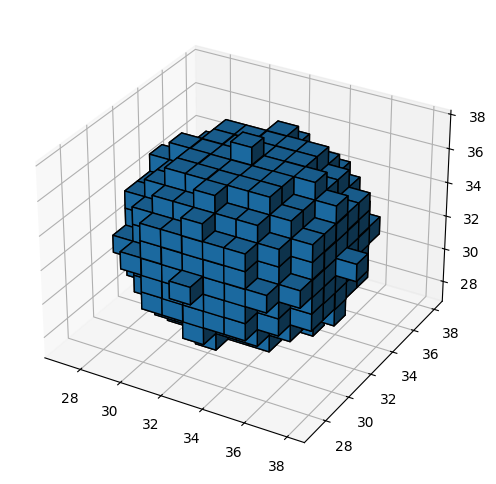

In [3]:
sphere = gl_utils.create_bin_sphere((64,64,64), (32,32,32), 5)
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(1,1,1, projection = '3d')
ax.voxels(sphere, edgecolor='k');

#### Ok, actually draw it on the brain this time

The function for this is `gl_utils.draw_mni_sphere()`, which has a lot of useful arguments:

**Required args**

* `mni_xyz` : MNI coordinates (RAS) of the sphere's center
* `arr_size` : Shape of your template brain; if array-like this is equivalent to `arr.shape`
* `radius` : mm radius of sphere
* `affine` : Affine matrix for transforming voxel-to-world coordinates. Loaded by nibabel

**Optional args**

* `coordsystem` : default `"ras"`, currently the only one supported
* `mask_by` : default `False`, if `True` then removes sphere voxels outside the given ROI (so this only works with other args passed too:)
    * `mask_atlas` : brain atlas to use for ROI coordinates. currently only `"harvard-oxford"` is supported
    * `mask_roi` : ROI name within `mask_atlas` to mask to
    * `p_thresh` : for probabilistic atlases, percent/100 probability that a voxel is in that ROI
* `fname` : default `None`, if a string is passed then saves the NIFTI to that file
* `debug` : default `False`, turns on a bunch of helpful print statements


For this example I am going to use a dict of MNI coordinates. The keys in this dict are the sphere names for the output NIFTI files and the values are the MNI coords.

In [4]:
radius = 8 # mm
seeds = {
    # These are for the R01 Figure 2
    # RED NETWORK - nfv
    'SMA' : [-2, 10, 46], # Battistella 2020
    'vPCSA' : [-56, 8, 20], # Beyond Broca 2023
    'dPCSA' : [-50, -4, 46], # Beyond Broca 2023
    'opIFG' : [-50, 10, 22], # Battistella 2020
    'SMG' : [-55, -34, 34], # Battistella 2020
    'aIns' : [-36, 1, 10], # Baldo 2011

    # YELLOW NETWORK - lv
    'Spt' : [-50, -42, 20], # Battistella 2020
    'MTG' : [-50, -54, 12], # Battistella 2020
    'rolandic' : [-54, -4, 8], # Battistella 2020
    'PoCG' : [-42, -14, 38], # Battistella 2020
    
    # GREEN NETWORK - sv
    'aMTG' : [-60, -6, -18], # Battistella 2020
    'AG' : [-46, -62, 34], # Battistella 2020
    
    # BLUE NETWORK- DMN
    'pITG' : [-54, -52, -10],
    'SPL' : [-28, -70, 46],
    'parstri' : [-48, 32, 20],
    'MTG' : [-62, -42, 0]
}
for k,v in seeds.items():
    _ = gl_utils.draw_mni_sphere(v, mni.shape, radius, mni.affine, mask_by=False,
                                 fname = f"{k}_{radius}mm.nii.gz")

Now if you load them in MRIcroGL you get something like this:
![](./media/ss.png)